## Construction of the Qubitization Walk Operator for Sparse Z-Matrices Arising in Financial Network Models 
### (Sparse Hamiltonian Simulation Using Qubitization For The Graph Laplacian-based SSL Problem)

In [1]:
"""
Notebook goal:
--------------
Construct the qubitization walk operator W corresponding
to the sparse Z-matrix

    A = (1 - alpha) I + alpha L

arising from Model 1 or Model 2.

This notebook stops after constructing W.

QPE and HHL are handled in a separate notebook.
"""

# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

# -----------------------
# Qiskit
# -----------------------
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator

# -----------------------
# Numerical libraries
# -----------------------
import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# -----------------------
# Plotting
# -----------------------
import matplotlib.pyplot as plt

# -----------------------
# Miscellaneous
# -----------------------
import math as m
import warnings

warnings.filterwarnings('ignore')

# -----------------------
# Custom utility functions
# -----------------------
import Our_Qiskit_Functions as oq

# ============================================================
# Simulators
# ============================================================

state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

# ============================================================
# Global NumPy settings
# ============================================================

np.set_printoptions(
    precision=4,
    suppress=True,
    linewidth=150
)

# ============================================================
# Random seed
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

print("Imports successful.")
print(f"Random seed = {SEED}")

Imports successful.
Random seed = 42


In [2]:
# ============================================================
# Cell 2 : Master Configuration
# ============================================================

# -----------------------
# Problem size
# -----------------------

# Total number of nodes INCLUDING dummy nodes.
# Must be a power of 2.
N = 1024

# Number of system qubits
n = int(np.log2(N))

assert 2**n == N, "N must be a power of 2."

# -----------------------
# Shock vector sparsity
# -----------------------

# gamma = 2^{ floor(log2( SHOCK_SPARSITY_FACTOR * log2(N) )) }

SHOCK_SPARSITY_FACTOR = 2

assert SHOCK_SPARSITY_FACTOR > 0, \
    "SHOCK_SPARSITY_FACTOR must be positive."

gamma = 2 ** int(
    np.floor(
        np.log2(
            SHOCK_SPARSITY_FACTOR * np.log2(N)
        )
    )
)

# gamma/2 dummy nodes are required
assert gamma % 2 == 0, "gamma must be even."

N_dummy = gamma // 2
N_real = N - N_dummy

assert N_real > 0, \
    "Number of real nodes must be positive."

# -----------------------
# Sparsity specification
# -----------------------

# Sparsity of J
#
# Every real node has exactly s_J neighbours.
#
# Since A = (1-alpha)I + alpha L,
# the diagonal contributes one additional nonzero,
# so
#
#     s = s_J + 1
#
s_J = 3

assert s_J >= 2, \
    "s_J must be at least 2."

# Sparsity of A
s = s_J + 1

# -----------------------
# Edge-weight specification
# -----------------------

# Minimum positive edge weight
J_min = 0.5

assert J_min > 0, \
    "J_min must be strictly positive."

# Ensure 1/J_min is an integer
assert np.isclose(
    1 / J_min,
    round(1 / J_min)
), "1/J_min must be an integer."

# All positive edge weights will be integer multiples of J_min:
#
#     J_ij = k_ij * J_min
#
# where
#
#     k_ij = 1, 2, 3, ...
#

# -----------------------
# Diffusion parameter
# -----------------------

alpha = 0.70

assert 0 < alpha < 1, \
    "alpha must lie strictly between 0 and 1."



# ============================================================
# Precision-design thresholds
# ============================================================

#
# These thresholds define the smallest meaningful
# values that the oracle value register must be
# capable of resolving.
#
# They are NOT the actual values used in the
# particular instance.
#
# Instead, they define the class of matrices
# that this notebook is designed to handle.
#

ALPHA_THRESHOLD = 1e-2

J_MIN_THRESHOLD = 1e-2



# -----------------------
# Model choice
# -----------------------

# 1 :
# A = (1-alpha)I + alpha(D - J)
#
# 2 :
# A = (1-alpha)I + alpha(I - D^{-1/2} J D^{-1/2})
#

#model = 1
model = 2

assert model in [1, 2], \
    "model must be either 1 or 2."

# -----------------------
# Real-network graph type
# -----------------------

# Allowed values:
#
# "nearest"
# "random_regular"
# "irregular"
#

#graph_type = "nearest"
#graph_type = "random_regular"
graph_type = "irregular"

assert graph_type in [
    "nearest",
    "random_regular",
    "irregular"
], "Invalid graph type."

# ============================================================
# Configuration summary
# ============================================================

print("=" * 65)
print("Master Configuration")
print("=" * 65)

print(f"Total nodes N                           : {N}")
print(f"System qubits n = log2(N)               : {n}")

print()

print(f"Shock sparsity factor                   : {SHOCK_SPARSITY_FACTOR}")
print(f"Shock sparsity gamma                    : {gamma}")
print(f"Dummy nodes (gamma/2)                   : {N_dummy}")
print(f"Real nodes                              : {N_real}")

print()

print(f"Sparsity of J (s_J)                     : {s_J}")
print(f"Sparsity of A (s = s_J + 1)             : {s}")

print()

print(f"Minimum edge weight J_min               : {J_min}")
print(f"1 / J_min                               : {int(round(1/J_min))}")

print("Positive edge weights are multiples of J_min")

print()

print(f"Diffusion parameter alpha               : {alpha}")
print(f"Model                                   : {model}")
print(f"Graph type                              : {graph_type}")

print("=" * 65)

Master Configuration
Total nodes N                           : 1024
System qubits n = log2(N)               : 10

Shock sparsity factor                   : 2
Shock sparsity gamma                    : 16
Dummy nodes (gamma/2)                   : 8
Real nodes                              : 1016

Sparsity of J (s_J)                     : 3
Sparsity of A (s = s_J + 1)             : 4

Minimum edge weight J_min               : 0.5
1 / J_min                               : 2
Positive edge weights are multiples of J_min

Diffusion parameter alpha               : 0.7
Model                                   : 2
Graph type                              : irregular


In [3]:
# ============================================================
# Cell 3 : Node Partitions and Index Sets
# ============================================================

# ------------------------------------------------------------
# Real bank nodes
# ------------------------------------------------------------

real_nodes = np.arange(N_real)

# ------------------------------------------------------------
# Dummy nodes
# ------------------------------------------------------------

dummy_nodes = np.arange(N_real, N)

# ------------------------------------------------------------
# Useful sets (for O(1) membership tests)
# ------------------------------------------------------------

real_node_set = set(real_nodes)
dummy_node_set = set(dummy_nodes)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

assert len(real_nodes) == N_real
assert len(dummy_nodes) == N_dummy

assert real_node_set.isdisjoint(dummy_node_set)

assert len(real_node_set.union(dummy_node_set)) == N

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 65)
print("Node Partition Summary")
print("=" * 65)

print(f"Total nodes (N)              : {N}")
print(f"Real nodes                   : {N_real}")
print(f"Dummy nodes                  : {N_dummy}")

print()

print(f"Real node indices            : "
      f"{real_nodes[0]} ... {real_nodes[-1]}")

if N_dummy > 0:
    print(f"Dummy node indices           : "
          f"{dummy_nodes[0]} ... {dummy_nodes[-1]}")
else:
    print("Dummy node indices           : None")

print()

print(f"Real node set size           : {len(real_node_set)}")
print(f"Dummy node set size          : {len(dummy_node_set)}")

print("=" * 65)

Node Partition Summary
Total nodes (N)              : 1024
Real nodes                   : 1016
Dummy nodes                  : 8

Real node indices            : 0 ... 1015
Dummy node indices           : 1016 ... 1023

Real node set size           : 1016
Dummy node set size          : 8


J_real Construction Summary
Graph type                          : irregular
Number of real nodes                : 1016

Specified s_J                       : 3
Specified sparsity of A (s)         : 4

Minimum actual row sparsity         : 1
Maximum actual row sparsity         : 3

Minimum weighted degree d_min       : 0.5000
Maximum weighted degree d_max       : 3.0000

Number of undirected edges          : 825
Number of non-zero entries          : 1650

Minimum positive J_ij               : 0.5000
Maximum positive J_ij               : 1.0000

First few rows of J_real:

Row 0:
    J[0,156] = 1.0
    J[0,690] = 0.5

Row 1:
    J[1,500] = 1.0

Row 2:
    J[2,83] = 0.5
    J[2,260] = 0.5
    J[2,467] = 1.0

Row 3:
    J[3,793] = 0.5

Row 4:
    J[4,94] = 1.0
    J[4,835] = 1.0
    J[4,942] = 1.0

Row 5:
    J[5,483] = 0.5

Row 6:
    J[6,239] = 1.0
    J[6,281] = 0.5
    J[6,680] = 1.0

Row 7:
    J[7,147] = 1.0

Row 8:
    J[8,50] = 0.5
    J[8,373] = 0.5

Row 9:
    J[9,206] = 0.5
    J

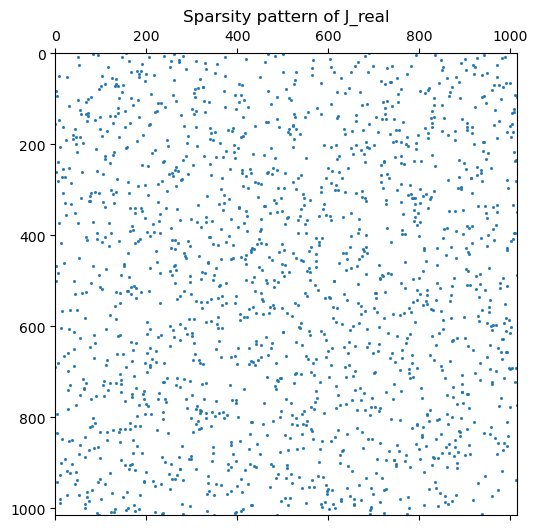

In [4]:
# ============================================================
# Cell 4 : Construct J_real
# ============================================================

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def generate_weight(J_min, rng):
    """
    Generate a positive edge weight that is an integer
    multiple of J_min and at most 1.

    Returns a value in

        {J_min, 2 J_min, ..., 1}
    """

    max_multiple = int(round(1 / J_min))

    multiplier = rng.integers(1, max_multiple + 1)

    return multiplier * J_min


# ------------------------------------------------------------
# Nearest-neighbour graph
# ------------------------------------------------------------

def generate_nearest_J(N_nodes,
                       J_min):
    """
    Construct a single cycle:

        0 -> 1 -> 2 -> ... -> N-1 -> 0

    All edge weights are J_min.

    Intended primarily for debugging and the case s_J = 2.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    for i in range(N_nodes):

        j = (i + 1) % N_nodes

        J[i, j] = J_min
        J[j, i] = J_min

    return J.tocsr()


# ------------------------------------------------------------
# Random "almost regular" graph
# ------------------------------------------------------------

def generate_random_regular_J(N_nodes,
                              s_J,
                              J_min,
                              rng):
    """
    Randomly partition the nodes.

    Groups of size (s_J + 1):
        Construct complete graphs K_{s_J+1}
        with edge weights J_min.

    Remainder group:
        Construct a simple cycle.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = rng.permutation(N_nodes)

    group_size = s_J + 1

    n_full_groups = N_nodes // group_size

    remainder = N_nodes % group_size

    # --------------------------------------------------------
    # Full groups
    # --------------------------------------------------------

    start = 0

    for _ in range(n_full_groups):

        group = nodes[start:start + group_size]

        start += group_size

        # Complete graph
        for i in range(len(group)):

            for j in range(i + 1,
                           len(group)):

                u = group[i]
                v = group[j]

                J[u, v] = J_min
                J[v, u] = J_min

    # --------------------------------------------------------
    # Remainder group
    # --------------------------------------------------------

    if remainder >= 2:

        group = nodes[start:]

        for i in range(len(group)):

            u = group[i]

            v = group[(i + 1) % len(group)]

            J[u, v] = J_min
            J[v, u] = J_min

    elif remainder == 1:

        print(
            "Warning: One node in the remainder "
            "group has no real-network connections."
        )

    return J.tocsr()


# ------------------------------------------------------------
# Irregular graph
# ------------------------------------------------------------

def generate_irregular_J(N_nodes,
                         s_J,
                         J_min,
                         rng):
    """
    Construct a general irregular graph.

    Procedure:
    1. Partition the nodes into groups whose sizes
       are random integers between 2 and s_J + 1.
    2. Within each group, consider all pairings.
    3. Assign each pairing a weight chosen from

            {0, J_min, 2J_min, ..., 1}

    4. Repair isolated nodes by assigning one
       incident edge weight J_min.

    Guarantees:
        - symmetric,
        - zero diagonal,
        - J_ij >= J_min whenever J_ij > 0,
        - d_i >= J_min for every node.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = list(rng.permutation(N_nodes))

    groups = []

    # --------------------------------------------------------
    # Create random groups
    # --------------------------------------------------------

    while len(nodes) > 0:

        remaining = len(nodes)

        if remaining <= s_J + 1:

            group_size = remaining

        else:

            group_size = rng.integers(
                2,
                s_J + 2
            )

        group = nodes[:group_size]

        groups.append(group)

        nodes = nodes[group_size:]

    # --------------------------------------------------------
    # Populate each group
    # --------------------------------------------------------

    max_multiple = int(round(1 / J_min))

    for group in groups:

        m = len(group)

        if m == 1:
            continue

        # --------------------------------------------
        # Random pairings
        # --------------------------------------------

        for i in range(m):

            for j in range(i + 1,
                           m):

                u = group[i]
                v = group[j]

                multiplier = rng.integers(
                    0,
                    max_multiple + 1
                )

                weight = multiplier * J_min

                if weight > 0:

                    J[u, v] = weight
                    J[v, u] = weight

        # --------------------------------------------
        # Repair isolated nodes
        # --------------------------------------------

        for u in group:

            degree = J[u, :].sum()

            if degree == 0:

                candidates = [
                    v for v in group
                    if v != u
                ]

                if len(candidates) > 0:

                    v = rng.choice(candidates)

                    J[u, v] = J_min
                    J[v, u] = J_min

    return J.tocsr()


# ============================================================
# Construct J_real
# ============================================================

if graph_type == "nearest":

    J_real = generate_nearest_J(
        N_real,
        J_min
    )

elif graph_type == "random_regular":

    J_real = generate_random_regular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

elif graph_type == "irregular":

    J_real = generate_irregular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

else:

    raise ValueError(
        f"Unknown graph type: {graph_type}"
    )


# ============================================================
# Diagnostics
# ============================================================

row_sparsities = np.diff(J_real.indptr)

weighted_degrees = np.array(
    J_real.sum(axis=1)
).flatten()

positive_entries = J_real.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_real != J_real.T).nnz == 0, \
    "J_real is not symmetric."

assert np.allclose(
    J_real.diagonal(),
    0
), "J_real has non-zero diagonal entries."

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Entries are not multiples of J_min."

assert np.all(
    row_sparsities <= s_J
), (
    "Actual sparsity exceeds specified s_J."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_real Construction Summary")
print("=" * 70)

print(f"Graph type                          : "
      f"{graph_type}")

print(f"Number of real nodes                : "
      f"{N_real}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Specified sparsity of A (s)         : "
      f"{s}")

print()

print(f"Minimum actual row sparsity         : "
      f"{row_sparsities.min()}")

print(f"Maximum actual row sparsity         : "
      f"{row_sparsities.max()}")

print()

print(f"Minimum weighted degree d_min       : "
      f"{weighted_degrees.min():.4f}")

print(f"Maximum weighted degree d_max       : "
      f"{weighted_degrees.max():.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J_real.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J_real.nnz}")

print()

print(f"Minimum positive J_ij               : "
      f"{positive_entries.min():.4f}")

print(f"Maximum positive J_ij               : "
      f"{positive_entries.max():.4f}")

print("=" * 70)

# ============================================================
# First few rows of J_real
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J_real:")

for i in range(n_rows_to_show):

    row = J_real.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J_real, markersize=1)
plt.title("Sparsity pattern of J_real")
plt.show()

J_dummy Construction Summary
Number of dummy nodes              : 8

Dummy node indices                 : [1016 1017 1018 1019 1020 1021 1022 1023]

Number of undirected dummy edges   : 8
Number of non-zero dummy entries   : 16

Dummy row sparsity                 : 2
Dummy weighted degree              : 1.0000

Dummy edge weight                  : 0.5

First few rows of dummy_subgraph in J_dummy:

Global node 1016:
    J[1016,1017] = 0.5
    J[1016,1023] = 0.5

Global node 1017:
    J[1017,1016] = 0.5
    J[1017,1018] = 0.5

Global node 1018:
    J[1018,1017] = 0.5
    J[1018,1019] = 0.5

Global node 1019:
    J[1019,1018] = 0.5
    J[1019,1020] = 0.5

Global node 1020:
    J[1020,1019] = 0.5
    J[1020,1021] = 0.5

Global node 1021:
    J[1021,1020] = 0.5
    J[1021,1022] = 0.5

Global node 1022:
    J[1022,1021] = 0.5
    J[1022,1023] = 0.5

Global node 1023:
    J[1023,1016] = 0.5
    J[1023,1022] = 0.5


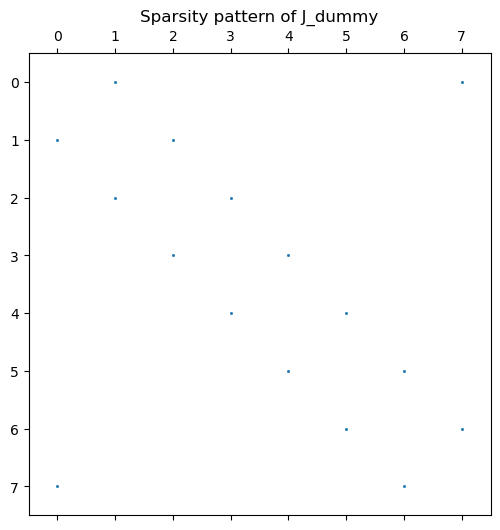

In [5]:
# ============================================================
# Cell 5 : Construct J_dummy
# ============================================================

J_dummy = sp.lil_matrix((N, N), dtype=float)

# ------------------------------------------------------------
# Construct the dummy cycle
# ------------------------------------------------------------

if N_dummy >= 2:

    for idx in range(N_dummy):

        u = dummy_nodes[idx]

        v = dummy_nodes[(idx + 1) % N_dummy]

        J_dummy[u, v] = J_min
        J_dummy[v, u] = J_min

elif N_dummy == 1:

    print(
        "Warning: Only one dummy node exists. "
        "No dummy edges created."
    )

else:

    print(
        "No dummy nodes specified."
    )

J_dummy = J_dummy.tocsr()


# ============================================================
# Diagnostics
# ============================================================

dummy_subgraph = J_dummy[dummy_nodes, :][:, dummy_nodes]

row_sparsities = np.diff(dummy_subgraph.indptr)

weighted_degrees = np.array(
    dummy_subgraph.sum(axis=1)
).flatten()

positive_entries = dummy_subgraph.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_dummy != J_dummy.T).nnz == 0, \
    "J_dummy is not symmetric."

assert np.allclose(
    J_dummy.diagonal(),
    0
), "J_dummy has non-zero diagonal entries."

# Ensure there are no real-dummy connections
assert J_dummy[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections found."

assert J_dummy[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections found."

if N_dummy >= 3:

    assert np.all(
        row_sparsities == 2
    ), "Dummy cycle does not have sparsity 2."

    assert np.allclose(
        weighted_degrees,
        2 * J_min
    ), (
        "Dummy weighted degrees are not equal "
        "to 2*J_min."
    )

if positive_entries.size > 0:

    assert np.allclose(
        positive_entries,
        J_min
    ), "Dummy edge weights are not equal to J_min."


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_dummy Construction Summary")
print("=" * 70)

print(f"Number of dummy nodes              : "
      f"{N_dummy}")

print()

print(f"Dummy node indices                 : "
      f"{dummy_nodes}")

print()

print(f"Number of undirected dummy edges   : "
      f"{dummy_subgraph.nnz // 2}")

print(f"Number of non-zero dummy entries   : "
      f"{dummy_subgraph.nnz}")

print()

if N_dummy >= 3:

    print(f"Dummy row sparsity                 : "
          f"{row_sparsities[0]}")

    print(f"Dummy weighted degree              : "
          f"{weighted_degrees[0]:.4f}")

print()

print(f"Dummy edge weight                  : "
      f"{J_min}")

print("=" * 70)

# ============================================================
# First few rows of J_dummy
# ============================================================

n_rows_to_show = min(dummy_subgraph.shape[0], 10)

print("\nFirst few rows of dummy_subgraph in J_dummy:")

for local_i in range(n_rows_to_show):

    global_i = dummy_nodes[local_i]

    row = dummy_subgraph.getrow(local_i)

    print(f"\nGlobal node {global_i}:")

    for local_j, val in zip(row.indices, row.data):

        global_j = dummy_nodes[local_j]

        print(
            f"    J[{global_i},{global_j}] = {val}"
        )


plt.figure(figsize=(6,6))
plt.spy(dummy_subgraph, markersize=1)
plt.title("Sparsity pattern of J_dummy")
plt.show()

Full Adjacency Matrix J Summary
Shape of J                          : (1024, 1024)

Number of real nodes                : 1016
Number of dummy nodes               : 8

Specified s_J                       : 3
Maximum actual row sparsity         : 3

d_min                               : 0.5000
d_max                               : 3.0000

Specified J_min                     : 0.5000
Actual minimum positive J_ij        : 0.5000
Actual maximum positive J_ij        : 1.0000

Number of undirected edges          : 833
Number of non-zero entries          : 1666

Number of connected components      : 346
Smallest component size             : 2
Largest component size              : 8

First few rows of J:

Row 0:
    J[0,156] = 1.0
    J[0,690] = 0.5

Row 1:
    J[1,500] = 1.0

Row 2:
    J[2,83] = 0.5
    J[2,260] = 0.5
    J[2,467] = 1.0

Row 3:
    J[3,793] = 0.5

Row 4:
    J[4,94] = 1.0
    J[4,835] = 1.0
    J[4,942] = 1.0

Row 5:
    J[5,483] = 0.5

Row 6:
    J[6,239] = 1.0
    J[6,281]

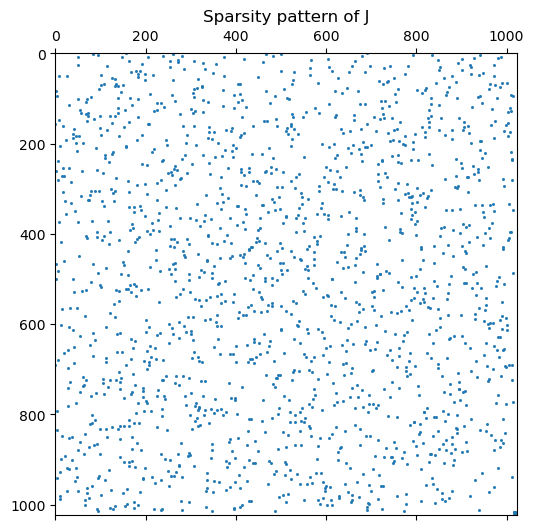

In [6]:
# ============================================================
# Cell 6 : Construct the full adjacency matrix J
# ============================================================

# ------------------------------------------------------------
# Embed J_real into an N x N matrix
# ------------------------------------------------------------

J_real_full = sp.lil_matrix((N, N), dtype=float)

J_real_full[:N_real, :N_real] = J_real

J_real_full = J_real_full.tocsr()

# ------------------------------------------------------------
# Assemble the full J matrix
# ------------------------------------------------------------

J = J_real_full + J_dummy

J = J.tocsr()

# ============================================================
# Diagnostics
# ============================================================

# ------------------------------------------------------------
# Basic structural properties
# ------------------------------------------------------------

assert J.shape == (N, N), \
    "J does not have shape (N, N)."

assert (J != J.T).nnz == 0, \
    "J is not symmetric."

assert np.allclose(
    J.diagonal(),
    0
), "J has non-zero diagonal entries."

# ------------------------------------------------------------
# Verify that real and dummy sectors are disconnected
# ------------------------------------------------------------

assert J[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections detected."

assert J[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections detected."

# ------------------------------------------------------------
# Sparsity diagnostics
# ------------------------------------------------------------

row_sparsities = np.diff(J.indptr)

max_row_sparsity = row_sparsities.max()

# ------------------------------------------------------------
# Weighted degree diagnostics
# ------------------------------------------------------------

weighted_degrees = np.array(
    J.sum(axis=1)
).flatten()

d_min = weighted_degrees.min()

d_max = weighted_degrees.max()

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert d_min >= J_min - 1e-12, \
    "d_min is smaller than J_min."

# ------------------------------------------------------------
# Edge-weight diagnostics
# ------------------------------------------------------------

positive_entries = J.data

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Some edge weights are not multiples of J_min."

J_ij_min_actual = positive_entries.min()

J_ij_max_actual = positive_entries.max()

# ------------------------------------------------------------
# Connected component diagnostics
# ------------------------------------------------------------

n_components, component_labels = sp.csgraph.connected_components(
    J,
    directed=False
)

component_sizes = np.bincount(component_labels)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Adjacency Matrix J Summary")
print("=" * 70)

print(f"Shape of J                          : "
      f"{J.shape}")

print()

print(f"Number of real nodes                : "
      f"{N_real}")

print(f"Number of dummy nodes               : "
      f"{N_dummy}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Maximum actual row sparsity         : "
      f"{max_row_sparsity}")

print()

print(f"d_min                               : "
      f"{d_min:.4f}")

print(f"d_max                               : "
      f"{d_max:.4f}")

print()

print(f"Specified J_min                     : "
      f"{J_min:.4f}")

print(f"Actual minimum positive J_ij        : "
      f"{J_ij_min_actual:.4f}")

print(f"Actual maximum positive J_ij        : "
      f"{J_ij_max_actual:.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J.nnz}")

print()

print(f"Number of connected components      : "
      f"{n_components}")

print(f"Smallest component size             : "
      f"{component_sizes.min()}")

print(f"Largest component size              : "
      f"{component_sizes.max()}")

print("=" * 70)

# ============================================================
# First few rows of J
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J:")

for i in range(n_rows_to_show):

    row = J.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J, markersize=1)
plt.title("Sparsity pattern of J")
plt.show()

In [7]:
# ============================================================
# Cell 7 : Construct D, L, and A
# ============================================================

# ------------------------------------------------------------
# Degree vector and degree matrix
# ------------------------------------------------------------

degree_vector = np.array(
    J.sum(axis=1)
).flatten()

D = sp.diags(
    degree_vector,
    offsets=0,
    shape=(N, N),
    format='csr'
)

# ============================================================
# Construct the Laplacian
# ============================================================

if model == 1:

    # --------------------------------------------------------
    # Model 1:
    #
    #     L = D - J
    #
    # --------------------------------------------------------

    L = D - J

elif model == 2:

    # --------------------------------------------------------
    # Model 2:
    #
    #     L = I - D^{-1/2} J D^{-1/2}
    #
    # --------------------------------------------------------

    D_inv_sqrt = sp.diags(
        1 / np.sqrt(degree_vector),
        offsets=0,
        shape=(N, N),
        format='csr'
    )

    L = (
        sp.eye(N, format='csr')
        - D_inv_sqrt @ J @ D_inv_sqrt
    )

else:

    raise ValueError(
        f"Unknown model: {model}"
    )

# ============================================================
# Construct A
# ============================================================

A = (
    (1 - alpha) * sp.eye(N, format='csr')
    + alpha * L
)

A = A.tocsr()

# ============================================================
# Diagnostics
# ============================================================

A_row_sparsities = np.diff(A.indptr)

A_diagonal = A.diagonal()

off_diagonal = A - sp.diags(
    A_diagonal,
    format='csr'
)

positive_off_diagonal_entries = (
    off_diagonal.data[
        off_diagonal.data > 1e-12
    ]
)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (A != A.T).nnz == 0, \
    "A is not symmetric."

assert np.all(
    A_diagonal > 0
), "A does not have positive diagonal entries."

assert len(
    positive_off_diagonal_entries
) == 0, (
    "A has positive off-diagonal entries "
    "and is therefore not a Z-matrix."
)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Matrix Construction Summary")
print("=" * 70)

print(f"Model used                          : "
      f"{model}")

print()

print(f"Diffusion parameter alpha           : "
      f"{alpha:.4f}")

print()

print(f"Minimum degree d_min                : "
      f"{degree_vector.min():.4f}")

print(f"Maximum degree d_max                : "
      f"{degree_vector.max():.4f}")

print()

print(f"Maximum row sparsity of A           : "
      f"{A_row_sparsities.max()}")

print()

print(f"Minimum diagonal entry of A         : "
      f"{A_diagonal.min():.4f}")

print(f"Maximum diagonal entry of A         : "
      f"{A_diagonal.max():.4f}")

print()

print(f"Number of non-zero entries in A     : "
      f"{A.nnz}")

print()

print(f"A is symmetric                      : True")

print(f"A is a Z-matrix                     : True")

print("=" * 70)

Matrix Construction Summary
Model used                          : 2

Diffusion parameter alpha           : 0.7000

Minimum degree d_min                : 0.5000
Maximum degree d_max                : 3.0000

Maximum row sparsity of A           : 4

Minimum diagonal entry of A         : 1.0000
Maximum diagonal entry of A         : 1.0000

Number of non-zero entries in A     : 2690

A is symmetric                      : True
A is a Z-matrix                     : True


In [8]:
# ============================================================
# Cell 8 : Spectral Diagnostics for A
# ============================================================

BLOCK_ENCODING_MARGIN = 1e-10

BOUND_VALIDATION_TOL = 1e-12
# (Used only when comparing exact theoretical bounds with numerically computed eigenvalues.)


# ------------------------------------------------------------
# Compute extremal eigenvalues
# ------------------------------------------------------------

print("Computing extremal eigenvalues of A...")

lambda_min = spla.eigsh(
    A,
    k=1,
    which='SA',
    return_eigenvectors=False
)[0]

lambda_max = spla.eigsh(
    A,
    k=1,
    which='LA',
    return_eigenvectors=False
)[0]

# ------------------------------------------------------------
# Exact condition number
# ------------------------------------------------------------

kappa_exact = lambda_max / lambda_min


# ============================================================
# Model-specific theoretical bounds
# ============================================================

if model == 1:

    #
    # A = (1-alpha)I + alpha(D - J)
    #
    # lambda_min >= 1 - alpha
    #
    # lambda_max <= (1-alpha) + 2 alpha d_max
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = (
        (1 - alpha)
        + 2 * alpha * d_max
    )

    row_sum_bound = 2*(s - 1)

elif model == 2:

    #
    # A = (1-alpha)I
    #   + alpha(I - D^{-1/2} J D^{-1/2})
    #
    # spectrum(A) subseteq [1-alpha, 1+alpha]
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = 1 + alpha

    row_sum_bound = s

else:

    raise ValueError(
        f"Unknown model: {model}"
    )


# ------------------------------------------------------------
# Theoretical condition number bound
# ------------------------------------------------------------

kappa_bound = (
    lambda_max_bound
    / lambda_min_bound
)


# ============================================================
# Positive definiteness diagnostics
# ============================================================

is_positive_definite = (
    lambda_min > 0
)

assert is_positive_definite, \
    (
        "A is not positive definite.\n"
        f"lambda_min = {lambda_min:.12f}"
    )


# ============================================================
# Validate theoretical bounds
# ============================================================

lower_bound_valid = (
    lambda_min >=
    lambda_min_bound - BOUND_VALIDATION_TOL
)

upper_bound_valid = (
    lambda_max <=
    lambda_max_bound + BOUND_VALIDATION_TOL
)

assert lower_bound_valid, \
    (
        "Theoretical lower bound violated.\n"
        f"lambda_min = {lambda_min:.12f}\n"
        f"lambda_min_bound = "
        f"{lambda_min_bound:.12f}"
    )

assert upper_bound_valid, \
    (
        "Theoretical upper bound violated.\n"
        f"lambda_max = {lambda_max:.12f}\n"
        f"lambda_max_bound = "
        f"{lambda_max_bound:.12f}"
    )


# ============================================================
# Block-encoding scaling factor
# ============================================================

# Note that alpha_A must ensure two things.
#
# 1. ||A / alpha_A||_2 <= 1,
#    so that the matrix is block-encodable.
#
# 2. For every row i,
#
#       sum_j |A_ij| / alpha_A <= 1,
#
#    so that the PREPARE amplitudes
#
#       sqrt(|A_ij| / alpha_A)
#
#    form a valid subnormalized state.
#    The remaining probability mass is assigned
#    to the |fail> state.

alpha_A = (
    max(
        lambda_max_bound,
        row_sum_bound
    )
    /
    (1 - BLOCK_ENCODING_MARGIN)
)

# ============================================================
# Encodability diagnostics
# ============================================================

scaled_lambda_min = (
    lambda_min / alpha_A
)

scaled_lambda_max = (
    lambda_max / alpha_A
)

all_eigenvalues_encodable = (
    scaled_lambda_max <= 1
)

assert all_eigenvalues_encodable, \
    (
        "Eigenvalues are not block-encodable.\n"
        f"lambda_max / alpha_A = "
        f"{scaled_lambda_max:.12f}"
    )

assert scaled_lambda_min > 0, \
    (
        "Scaled eigenvalues are not positive.\n"
        f"lambda_min / alpha_A = "
        f"{scaled_lambda_min:.12f}"
    )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Spectral Diagnostics")
print("=" * 70)

print(f"Exact lambda_min                   : "
      f"{lambda_min:.8f}")

print(f"Exact lambda_max                   : "
      f"{lambda_max:.8f}")

print()

print(f"Exact condition number             : "
      f"{kappa_exact:.8f}")

print()

print(f"Theoretical lambda_min bound       : "
      f"{lambda_min_bound:.8f}")

print(f"Theoretical lambda_max bound       : "
      f"{lambda_max_bound:.8f}")

print()

print(f"Theoretical condition number bound : "
      f"{kappa_bound:.8f}")

print()

print(f"Row-sum bound                      : "
      f"{row_sum_bound:.8f}")

print()

print(f"Block-encoding margin              : "
      f"{BLOCK_ENCODING_MARGIN:.2e}")

print(f"Block-encoding scaling alpha_A     : "
      f"{alpha_A:.8f}")

print()

print(f"lambda_min / alpha_A               : "
      f"{scaled_lambda_min:.8f}")

print(f"lambda_max / alpha_A               : "
      f"{scaled_lambda_max:.8f}")

print(f"alpha_A / lambda_max               : "
      f"{alpha_A / lambda_max:.8f}")

print()

print(f"A is positive definite             : "
      f"{is_positive_definite}")

print(f"Lower bound validated              : "
      f"{lower_bound_valid}")

print(f"Upper bound validated              : "
      f"{upper_bound_valid}")

print(f"All eigenvalues encodable          : "
      f"{all_eigenvalues_encodable}")

print("=" * 70)

Computing extremal eigenvalues of A...

Spectral Diagnostics
Exact lambda_min                   : 0.30000000
Exact lambda_max                   : 1.70000000

Exact condition number             : 5.66666667

Theoretical lambda_min bound       : 0.30000000
Theoretical lambda_max bound       : 1.70000000

Theoretical condition number bound : 5.66666667

Row-sum bound                      : 4.00000000

Block-encoding margin              : 1.00e-10
Block-encoding scaling alpha_A     : 4.00000000

lambda_min / alpha_A               : 0.07500000
lambda_max / alpha_A               : 0.42500000
alpha_A / lambda_max               : 2.35294118

A is positive definite             : True
Lower bound validated              : True
Upper bound validated              : True
All eigenvalues encodable          : True


In [9]:
# ============================================================
# Cell 9 : Construct Sparse Oracle Tables for A
# ============================================================

A_positions = []
A_values = []

# ------------------------------------------------------------
# Extract sparse representation row by row
# ------------------------------------------------------------

for i in range(N):

    row = A.getrow(i)

    positions = row.indices.tolist()
    values = row.data.tolist()

    # --------------------------------------------------------
    # Verify sparsity assumption
    # --------------------------------------------------------

    assert len(positions) <= s, \
        (
            f"Row {i} exceeds sparsity bound.\n"
            f"Observed sparsity = {len(positions)}\n"
            f"Specified sparsity = {s}"
        )

    A_positions.append(positions)
    A_values.append(values)


# ============================================================
# Pad the rows to uniform length s
# ============================================================

#
# O_F expects a mapping
#
#     (i, ell) -> f(i, ell)
#
# where ell ∈ {0, ..., s−1}.
#
# Therefore, every row representation should have
# exactly s entries.
#
# Padding is performed using actual zero locations
# (p, 0) satisfying A[i, p] = 0.
#
# We additionally ensure that the final position list
# is sorted in ascending order.
#

A_positions_padded = []
A_values_padded = []

for i in range(N):

    positions = A_positions[i].copy()
    values = A_values[i].copy()

    # --------------------------------------------------------
    # Sort the genuine entries
    # --------------------------------------------------------

    pairs = sorted(
        zip(positions, values),
        key=lambda x: x[0]
    )

    positions = [p for p, _ in pairs]
    values = [v for _, v in pairs]

    # --------------------------------------------------------
    # Pad using actual zero locations
    # --------------------------------------------------------

    padding_needed = s - len(positions)

    if padding_needed > 0:

        used_positions = set(positions)

        available_positions = [
            j for j in range(N)
            if j not in used_positions
        ]

        padding_positions = (
            available_positions[:padding_needed]
        )

        positions.extend(padding_positions)

        values.extend(
            [0.0] * padding_needed
        )

    # --------------------------------------------------------
    # Final sorting (including padded entries)
    # --------------------------------------------------------

    pairs = sorted(
        zip(positions, values),
        key=lambda x: x[0]
    )

    positions = [p for p, _ in pairs]
    values = [v for _, v in pairs]

    # --------------------------------------------------------
    # Final checks
    # --------------------------------------------------------

    assert len(positions) == s, \
        (
            f"Row {i} does not have exactly "
            f"{s} padded entries."
        )

    assert len(values) == s, \
        (
            f"Row {i} does not have exactly "
            f"{s} padded values."
        )

    A_positions_padded.append(positions)
    A_values_padded.append(values)


# ============================================================
# Convert to NumPy arrays
# ============================================================

A_positions_padded = np.array(
    A_positions_padded,
    dtype=int
)

A_values_padded = np.array(
    A_values_padded,
    dtype=float
)


# ============================================================
# Verify consistency with A
# ============================================================

for i in range(N):

    for ell in range(s):

        j = A_positions_padded[i, ell]

        val = A_values_padded[i, ell]

        actual_val = A[i, j]

        if sp.issparse(actual_val):

            actual_val = actual_val.toarray()[0, 0]

        actual_val = float(actual_val)

        assert np.isclose(
            val,
            actual_val
        ), (
            f"Inconsistent oracle entry.\n"
            f"Row {i}, ell = {ell}\n"
            f"Position = {j}\n"
            f"Stored value = {val}\n"
            f"Actual value = {actual_val}"
        )


# ============================================================
# Diagnostics
# ============================================================

assert A_positions_padded.shape == (N, s)

assert A_values_padded.shape == (N, s)

assert np.all(
    np.diff(A_positions_padded, axis=1) >= 0
), (
    "Some rows are not sorted in ascending order."
)

assert np.all(
    np.sum(
        A_values_padded != 0,
        axis=1
    ) <= s
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Sparse Oracle Tables for A")
print("=" * 70)

print(f"A_positions_padded shape            : "
      f"{A_positions_padded.shape}")

print(f"A_values_padded shape               : "
      f"{A_values_padded.shape}")

print()

print(f"Specified sparsity s                : "
      f"{s}")

print()

print("First few rows:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for ell in range(s):

        j = A_positions_padded[i, ell]

        val = A_values_padded[i, ell]

        print(
            f"    ell = {ell}: "
            f"column = {j}, "
            f"value = {val:.6f}"
        )

print("\n" + "=" * 70)

Sparse Oracle Tables for A
A_positions_padded shape            : (1024, 4)
A_values_padded shape               : (1024, 4)

Specified sparsity s                : 4

First few rows:

Row 0:
    ell = 0: column = 0, value = 1.000000
    ell = 1: column = 1, value = 0.000000
    ell = 2: column = 156, value = -0.404145
    ell = 3: column = 690, value = -0.233333

Row 1:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 1, value = 1.000000
    ell = 2: column = 2, value = 0.000000
    ell = 3: column = 500, value = -0.700000

Row 2:
    ell = 0: column = 2, value = 1.000000
    ell = 1: column = 83, value = -0.247487
    ell = 2: column = 260, value = -0.247487
    ell = 3: column = 467, value = -0.350000

Row 3:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 1, value = 0.000000
    ell = 2: column = 3, value = 1.000000
    ell = 3: column = 793, value = -0.313050

Row 4:
    ell = 0: column = 4, value = 1.000000
    ell = 1: column = 94, value = -0.285774
 

In [10]:
# ============================================================
# Cell 10 : Classical Sparse Oracles O_F and O_A
# ============================================================

# ------------------------------------------------------------
# Position oracle:
#
#     O_F(i, ell) = f(i, ell)
#
# Returns the column index corresponding to the
# ell-th accessible entry of row i.
# ------------------------------------------------------------

def O_F(i, ell):

    assert 0 <= i < N, \
        f"Row index i = {i} is out of range."

    assert 0 <= ell < s, \
        f"Sparsity index ell = {ell} is out of range."

    return int(
        A_positions_padded[i, ell]
    )


# ------------------------------------------------------------
# Value oracle:
#
#     O_A(i, ell)
#
# Returns the matrix value
#
#     A_{i, f(i, ell)}.
#
# ------------------------------------------------------------

def O_A(i, ell):

    assert 0 <= i < N, \
        f"Row index i = {i} is out of range."

    assert 0 <= ell < s, \
        f"Sparsity index ell = {ell} is out of range."

    return float(
        A_values_padded[i, ell]
    )


# ============================================================
# Exhaustive verification
# ============================================================

for i in range(N):

    for ell in range(s):

        j = O_F(i, ell)

        oracle_value = O_A(i, ell)

        actual_value = A[i, j]

        if sp.issparse(actual_value):

            actual_value = actual_value.toarray()[0, 0]

        actual_value = float(actual_value)

        assert np.isclose(
            oracle_value,
            actual_value
        ), (
            f"Oracle mismatch.\n"
            f"Row = {i}\n"
            f"ell = {ell}\n"
            f"O_F(i, ell) = {j}\n"
            f"O_A(i, ell) = {oracle_value}\n"
            f"A[i, j] = {actual_value}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Classical Sparse Oracle Verification")
print("=" * 70)

print(
    "Position oracle O_F verified "
    f"for all {N*s} entries."
)

print(
    "Value oracle O_A verified "
    f"for all {N*s} entries."
)

print("\nExample queries:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for ell in range(s):

        j = O_F(i, ell)

        val = O_A(i, ell)

        print(
            f"    ell = {ell}: "
            f"f(i, ell) = {j}, "
            f"A[i, f(i, ell)] = {val:.6f}"
        )

print("\n" + "=" * 70)

Classical Sparse Oracle Verification
Position oracle O_F verified for all 4096 entries.
Value oracle O_A verified for all 4096 entries.

Example queries:

Row 0:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 1.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 0.000000
    ell = 2: f(i, ell) = 156, A[i, f(i, ell)] = -0.404145
    ell = 3: f(i, ell) = 690, A[i, f(i, ell)] = -0.233333

Row 1:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 2, A[i, f(i, ell)] = 0.000000
    ell = 3: f(i, ell) = 500, A[i, f(i, ell)] = -0.700000

Row 2:
    ell = 0: f(i, ell) = 2, A[i, f(i, ell)] = 1.000000
    ell = 1: f(i, ell) = 83, A[i, f(i, ell)] = -0.247487
    ell = 2: f(i, ell) = 260, A[i, f(i, ell)] = -0.247487
    ell = 3: f(i, ell) = 467, A[i, f(i, ell)] = -0.350000

Row 3:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 0.000000
    ell = 2: f(i, ell) = 3,

In [11]:
# ============================================================
# Cell 11 : Oracle Register Specifications
# ============================================================

# ------------------------------------------------------------
# Upper bound on d_max
# ------------------------------------------------------------

#
# Since
#
#     J_ij <= 1,
#
# and each node has at most s_J neighbors,
#
# we have
#
#     d_max <= s_J.
#
# This bound depends only on the problem
# specification and NOT on the realized graph.
#

d_max_possible = s_J


# ============================================================
# Model-1 precision requirements
# ============================================================

#
# For Model 1:
#
#     |A_ij| = alpha J_ij
#
# Therefore,
#
#     |A_ij|
#
#     >= ALPHA_THRESHOLD J_MIN_THRESHOLD.
#

A_min_possible_model_1 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
)

#
# Since
#
#     A_ii
#
#     = 1 - alpha + alpha d_i
#
# and
#
#     d_i <= d_max_possible,
#
# we obtain
#
#     A_ii <= 1 + d_max_possible.
#

A_max_possible_model_1 = (
    1
    + d_max_possible
)


# ============================================================
# Model-2 precision requirements
# ============================================================

#
# For Model 2:
#
#     |A_ij|
#
#     = alpha J_ij
#
#       / sqrt(d_i d_j)
#
# Since
#
#     sqrt(d_i d_j)
#
#     <= d_max_possible,
#
# we obtain
#
#     |A_ij|
#
#     >=
#
#     ALPHA_THRESHOLD
#
#     * J_MIN_THRESHOLD
#
#     / d_max_possible.
#

A_min_possible_model_2 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
    / d_max_possible
)

#
# Diagonal entries are exactly 1.
#

A_max_possible_model_2 = 1.0


# ============================================================
# Model-agnostic precision requirements
# ============================================================

#
# We construct ONE oracle architecture that
# works for BOTH models.
#
# Therefore, we first determine the largest
# possible matrix entry magnitude among all
# models under consideration.
#

A_max_possible = max(
    A_max_possible_model_1,
    A_max_possible_model_2
)


#
# Require
#
#     A_max_possible / 2^b
#
# to be strictly smaller than the smallest
# representable nonzero entry in each model.
#

ratio_model_1 = (
    A_max_possible
    / A_min_possible_model_1
)

ratio_model_2 = (
    A_max_possible
    / A_min_possible_model_2
)


#
# Add one extra bit to guarantee the strict
# inequality.
#

VALUE_PRECISION_BITS_MODEL_1 = int(
    np.ceil(
        np.log2(ratio_model_1)
    )
) + 1

VALUE_PRECISION_BITS_MODEL_2 = int(
    np.ceil(
        np.log2(ratio_model_2)
    )
) + 1


#
# Model-agnostic value precision.
#

VALUE_PRECISION_BITS = max(
    VALUE_PRECISION_BITS_MODEL_1,
    VALUE_PRECISION_BITS_MODEL_2
)


VALUE_RESOLUTION = (
    A_max_possible
    /
    (2 ** VALUE_PRECISION_BITS)
)


# ------------------------------------------------------------
# Verify that the chosen precision is sufficient
# ------------------------------------------------------------

assert VALUE_RESOLUTION < A_min_possible_model_1, \
    (
        "Value register precision is insufficient "
        "for Model 1.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_1 = "
        f"{A_min_possible_model_1:.12e}"
    )

assert VALUE_RESOLUTION < A_min_possible_model_2, \
    (
        "Value register precision is insufficient "
        "for Model 2.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_2 = "
        f"{A_min_possible_model_2:.12e}"
    )


# ============================================================
# Determine actual realized A diagnostics
# ============================================================

A_nonzero_values = A.data

A_nonzero_magnitudes = np.abs(
    A_nonzero_values[
        np.abs(A_nonzero_values) > 0
    ]
)

A_min_actual = (
    A_nonzero_magnitudes.min()
)

A_max_actual = (
    A_nonzero_magnitudes.max()
)

actual_entries_resolvable = (
    A_min_actual
    > VALUE_RESOLUTION
)

assert actual_entries_resolvable, \
    (
        "The realized matrix A contains "
        "entries below the chosen value "
        "resolution.\n"
        f"A_min_actual = "
        f"{A_min_actual:.12e}\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}"
    )


# ============================================================
# Register sizes
# ============================================================

#
# Index register
#

n_index = n


#
# Sparsity register
#

n_sparsity = int(
    np.ceil(
        np.log2(s)
    )
)


#
# Position register
#

n_position = n


#
# Sign qubit
#

n_sign = 1


#
# Value register
#

n_value = (
    VALUE_PRECISION_BITS
    + n_sign
)


# ============================================================
# Oracle logical qubit counts
# ============================================================

n_qubits_O_F = (
    n_index
    + n_sparsity
    + n_position
)

n_qubits_O_A = (
    n_index
    + n_sparsity
    + n_value
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Oracle Register Specifications")
print("=" * 70)

print(f"ALPHA_THRESHOLD                   : "
      f"{ALPHA_THRESHOLD:.2e}")

print(f"J_MIN_THRESHOLD                   : "
      f"{J_MIN_THRESHOLD:.2e}")

print()

print(f"d_max_possible                    : "
      f"{d_max_possible}")

print()

print(f"Model-1 A_min_possible            : "
      f"{A_min_possible_model_1:.12e}")

print(f"Model-1 A_max_possible            : "
      f"{A_max_possible_model_1:.12e}")

print(f"Model-1 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_1}")

print()

print(f"Model-2 A_min_possible            : "
      f"{A_min_possible_model_2:.12e}")

print(f"Model-2 A_max_possible            : "
      f"{A_max_possible_model_2:.12e}")

print(f"Model-2 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_2}")

print()

print(f"Model-agnostic A_max_possible     : "
      f"{A_max_possible:.12e}")

print(f"Model-agnostic precision bits     : "
      f"{VALUE_PRECISION_BITS}")

print(f"Model-agnostic resolution         : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print(f"Actual A_min                      : "
      f"{A_min_actual:.12e}")

print(f"Actual A_max                      : "
      f"{A_max_actual:.12e}")

print()

print(f"Actual entries resolvable         : "
      f"{actual_entries_resolvable}")

print()

print(f"Index register qubits             : "
      f"{n_index}")

print(f"Sparsity register qubits          : "
      f"{n_sparsity}")

print(f"Position register qubits          : "
      f"{n_position}")

print(f"Value register qubits             : "
      f"{n_value}")

print()

print(f"O_F logical qubits                : "
      f"{n_qubits_O_F}")

print(f"O_A logical qubits                : "
      f"{n_qubits_O_A}")

print()

print("Ancilla qubits required for")
print("QROM implementation are not")
print("included in these counts.")

print("=" * 70)

Oracle Register Specifications
ALPHA_THRESHOLD                   : 1.00e-02
J_MIN_THRESHOLD                   : 1.00e-02

d_max_possible                    : 3

Model-1 A_min_possible            : 1.000000000000e-04
Model-1 A_max_possible            : 4.000000000000e+00
Model-1 precision bits            : 17

Model-2 A_min_possible            : 3.333333333333e-05
Model-2 A_max_possible            : 1.000000000000e+00
Model-2 precision bits            : 18

Model-agnostic A_max_possible     : 4.000000000000e+00
Model-agnostic precision bits     : 18
Model-agnostic resolution         : 1.525878906250e-05

Actual A_min                      : 1.565247584250e-01
Actual A_max                      : 1.000000000000e+00

Actual entries resolvable         : True

Index register qubits             : 10
Sparsity register qubits          : 2
Position register qubits          : 10
Value register qubits             : 19

O_F logical qubits                : 22
O_A logical qubits                : 31

A

In [12]:
# ============================================================
# Cell 12 : QROM Data Preparation
# ============================================================

# ------------------------------------------------------------
# Flatten O_F lookup table
# ------------------------------------------------------------

#
# Address convention:
#
#     address = i * s + ell
#
# where
#
#     i   = row index,
#     ell = sparsity index.
#

num_addresses = N * s

O_F_table = np.zeros(
    num_addresses,
    dtype=int
)

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        O_F_table[address] = (
            A_positions_padded[i, ell]
        )


# ------------------------------------------------------------
# Flatten O_A lookup table
# ------------------------------------------------------------

#
# We encode values using
#
#     sign bit
#
# together with a fixed-point magnitude.
#

O_A_sign_table = np.zeros(
    num_addresses,
    dtype=int
)

O_A_magnitude_table = np.zeros(
    num_addresses,
    dtype=int
)

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        value = (
            A_values_padded[i, ell]
        )

        #
        # Sign bit
        #
        #     0 -> positive
        #     1 -> negative
        #

        if value < 0:

            O_A_sign_table[address] = 1

        else:

            O_A_sign_table[address] = 0

        #
        # Fixed-point magnitude
        #

        magnitude = abs(value)

        encoded_magnitude = int(
            np.round(
                magnitude
                / VALUE_RESOLUTION
            )
        )

        O_A_magnitude_table[address] = (
            encoded_magnitude
        )


# ============================================================
# Verify fixed-point encoding
# ============================================================

maximum_encoding_error = 0.0

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        original_value = (
            A_values_padded[i, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        maximum_encoding_error = max(
            maximum_encoding_error,
            encoding_error
        )

        assert (
            encoding_error
            <= VALUE_RESOLUTION
        ), (
            f"Fixed-point encoding error too large.\n"
            f"Address = {address}\n"
            f"Original value = {original_value}\n"
            f"Decoded value = {decoded_value}\n"
            f"Error = {encoding_error}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("QROM Data Preparation")
print("=" * 70)

print(f"Number of addresses               : "
      f"{num_addresses}")

print()

print(f"O_F table size                    : "
      f"{len(O_F_table)}")

print(f"O_A sign table size               : "
      f"{len(O_A_sign_table)}")

print(f"O_A magnitude table size          : "
      f"{len(O_A_magnitude_table)}")

print()

print(f"Maximum encoding error            : "
      f"{maximum_encoding_error:.12e}")

print(f"Value resolution                  : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print("Example entries:")

n_examples = min(10, num_addresses)

for address in range(n_examples):

    i = address // s

    ell = address % s

    print(
        f"\nAddress {address}: "
        f"(i={i}, ell={ell})"
    )

    print(
        f"    Position      : "
        f"{O_F_table[address]}"
    )

    original_value = (
        A_values_padded[i, ell]
    )
    
    sign = (
        -1
        if O_A_sign_table[address] == 1
        else 1
    )
    
    decoded_value = (
        sign
        * O_A_magnitude_table[address]
        * VALUE_RESOLUTION
    )
    
    encoding_error = abs(
        original_value
        - decoded_value
    )
    
    print(
        f"    Original value : "
        f"{original_value:.12f}"
    )
    
    print(
        f"    Sign bit       : "
        f"{O_A_sign_table[address]}"
    )
    
    print(
        f"    Magnitude int  : "
        f"{O_A_magnitude_table[address]}"
    )
    
    print(
        f"    Decoded value  : "
        f"{decoded_value:.12f}"
    )
    
    print(
        f"    Encoding error : "
        f"{encoding_error:.12e}"
    )

print("\n" + "=" * 70)


QROM_VALIDATION_THRESHOLD = (
    maximum_encoding_error
    + VALUE_RESOLUTION
) / 2

all_entries_verified = True

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        original_value = (
            A_values_padded[i, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        if (
            encoding_error
            > QROM_VALIDATION_THRESHOLD
        ):

            all_entries_verified = False

            print(
                "\nValidation failure:"
            )

            print(
                f"Address = {address}"
            )

            print(
                f"Original value = "
                f"{original_value:.12f}"
            )

            print(
                f"Decoded value = "
                f"{decoded_value:.12f}"
            )

            print(
                f"Encoding error = "
                f"{encoding_error:.12e}"
            )

assert all_entries_verified, \
    (
        "QROM validation failed."
    )

print()

print(
    f"QROM validation threshold         : "
    f"{QROM_VALIDATION_THRESHOLD:.12e}"
)

print(
    f"All entries validated             : "
    f"{all_entries_verified}"
)

QROM Data Preparation
Number of addresses               : 4096

O_F table size                    : 4096
O_A sign table size               : 4096
O_A magnitude table size          : 4096

Maximum encoding error            : 7.201762204145e-06
Value resolution                  : 1.525878906250e-05

Example entries:

Address 0: (i=0, ell=0)
    Position      : 0
    Original value : 1.000000000000
    Sign bit       : 0
    Magnitude int  : 65536
    Decoded value  : 1.000000000000
    Encoding error : 0.000000000000e+00

Address 1: (i=0, ell=1)
    Position      : 1
    Original value : 0.000000000000
    Sign bit       : 0
    Magnitude int  : 0
    Decoded value  : 0.000000000000
    Encoding error : 0.000000000000e+00

Address 2: (i=0, ell=2)
    Position      : 156
    Original value : -0.404145188433
    Sign bit       : 1
    Magnitude int  : 26486
    Decoded value  : -0.404144287109
    Encoding error : 9.013233630562e-07

Address 3: (i=0, ell=3)
    Position      : 690
    Orig

In [13]:
# ============================================================
# Cell 13 : Logical Specification of Sparse Oracles
# ============================================================

# ------------------------------------------------------------
# Address register
# ------------------------------------------------------------

#
# Address convention:
#
#     address = i * s + ell
#
# where
#
#     i   = row index,
#     ell = sparsity index.
#

n_addresses = N * s

n_address = int(
    np.ceil(
        np.log2(n_addresses)
    )
)


# ============================================================
# Oracle interfaces
# ============================================================

#
# O_F:
#
#     |address>|0>
#
#         ->
#
#     |address>|position>
#
#
# O_A:
#
#     |address>|0>|0>
#
#         ->
#
#     |address>|sign>|magnitude>
#


# ------------------------------------------------------------
# Classical emulation of O_F
# ------------------------------------------------------------

def O_F_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    return int(
        O_F_table[address]
    )


# ------------------------------------------------------------
# Classical emulation of O_A
# ------------------------------------------------------------

def O_A_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    sign = int(
        O_A_sign_table[address]
    )

    magnitude = int(
        O_A_magnitude_table[address]
    )

    return sign, magnitude


# ------------------------------------------------------------
# Decode O_A output
# ------------------------------------------------------------

def decode_O_A(sign, magnitude):

    decoded_sign = (
        -1
        if sign == 1
        else 1
    )

    return (
        decoded_sign
        * magnitude
        * VALUE_RESOLUTION
    )


# ============================================================
# Verify address mapping
# ============================================================

for address in range(n_addresses):

    #
    # Recover (i, ell)
    #

    i = address // s

    ell = address % s

    #
    # Oracle outputs
    #

    position = O_F_address(address)

    sign, magnitude = (
        O_A_address(address)
    )

    decoded_value = decode_O_A(
        sign,
        magnitude
    )

    #
    # Gold-standard values
    #

    expected_position = (
        A_positions_padded[i, ell]
    )

    expected_value = (
        A[i, expected_position]
    )

    if sp.issparse(expected_value):

        expected_value = (
            expected_value.toarray()[0, 0]
        )

    expected_value = float(
        expected_value
    )

    #
    # Verify position oracle
    #

    assert (
        position
        == expected_position
    ), (
        f"Position mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_position}\n"
        f"Obtained = {position}"
    )

    #
    # Verify value oracle
    #

    assert (
        abs(
            decoded_value
            - expected_value
        )
        <= VALUE_RESOLUTION
    ), (
        f"Value mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_value}\n"
        f"Decoded = {decoded_value}"
    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Logical Sparse Oracle Specification")
print("=" * 70)

print(f"Number of addresses               : "
      f"{n_addresses}")

print(f"Address register qubits           : "
      f"{n_address}")

print()

print(f"Position output qubits            : "
      f"{n_position}")

print()

print(f"Sign output qubits                : "
      f"{n_sign}")

print(f"Magnitude output qubits           : "
      f"{VALUE_PRECISION_BITS}")

print(f"Value output qubits               : "
      f"{n_value}")

print()

print("Oracle interfaces:")

print()

print("O_F :")

print(
    f"    |address> |0> "
    f"-> "
    f"|address> |position>"
)

print()

print("O_A :")

print(
    f"    |address> |0> |0> "
    f"-> "
    f"|address> |sign> |magnitude>"
)

print()

print("All logical oracle checks passed.")

print("=" * 70)

Logical Sparse Oracle Specification
Number of addresses               : 4096
Address register qubits           : 12

Position output qubits            : 10

Sign output qubits                : 1
Magnitude output qubits           : 18
Value output qubits               : 19

Oracle interfaces:

O_F :
    |address> |0> -> |address> |position>

O_A :
    |address> |0> |0> -> |address> |sign> |magnitude>

All logical oracle checks passed.


In [14]:
# ============================================================
# Cell 14 : PREPARE State Construction
# ============================================================

#
# Register convention used from Cell 16 onward:
#
#     |ancilla>|row>|system>
#
# PREPARE acts on the ancilla and row
# registers according to
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
#     =
#
#     sum_ell
#
#         sqrt(
#             |A_{i,f(i,ell)}|
#             / alpha_A
#         )
#
#         |ell>
#
#     +
#
#     sqrt(
#         1
#         -
#         sum_ell
#             |A_{i,f(i,ell)}|
#             / alpha_A
#     )
#
#         |fail>.
#
# The system register is unaffected
# by PREPARE.
#

# ------------------------------------------------------------
# PREPARE register specifications
# ------------------------------------------------------------

#
# Need:
#
#     s sparsity states
#
# plus
#
#     1 failure state.
#

PREPARE_DIMENSION = s + 1

n_prepare = int(
    np.ceil(
        np.log2(PREPARE_DIMENSION)
    )
)

FAILURE_INDEX = s


# ============================================================
# Construct PREPARE states
# ============================================================

#
# prepare_states[i,:] stores the amplitudes
# of |chi_i>.
#
# These amplitudes determine the action
#
#     |0>|i> --> |chi_i>|i>,
#
# but do not themselves depend on the
# eventual ordering of registers in the
# quantum circuit.
#

prepare_states = np.zeros(
    (N, PREPARE_DIMENSION)
)

prepare_row_sums = np.zeros(N)

for i in range(N):

    #
    # Populate amplitudes
    #

    for ell in range(s):

        value = abs(
            A_values_padded[i, ell]
        )

        prepare_row_sums[i] += (
            value / alpha_A
        )

        prepare_states[i, ell] = np.sqrt(
            value / alpha_A
        )

    #
    # Failure amplitude
    #

    failure_probability = (
        1.0
        - prepare_row_sums[i]
    )

    assert failure_probability >= 0, (
        f"PREPARE normalization failed "
        f"for row {i}.\n"
        f"Failure probability = "
        f"{failure_probability}"
    )

    prepare_states[
        i,
        FAILURE_INDEX
    ] = np.sqrt(
        failure_probability
    )


# ============================================================
# Verify normalization
# ============================================================

prepare_norms = np.sum(
    prepare_states**2,
    axis=1
)

prepare_states_normalized = np.allclose(
    prepare_norms,
    1.0
)

assert prepare_states_normalized, (
    "Some PREPARE states are not normalized."
)


# ============================================================
# Diagnostics
# ============================================================

minimum_failure_probability = np.min(
    prepare_states[:, FAILURE_INDEX]**2
)

maximum_failure_probability = np.max(
    prepare_states[:, FAILURE_INDEX]**2
)

mean_failure_probability = np.mean(
    prepare_states[:, FAILURE_INDEX]**2
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE State Construction (Ancilla-First Convention)")
print("=" * 70)

print(f"PREPARE dimension                : "
      f"{PREPARE_DIMENSION}")

print(f"PREPARE register qubits          : "
      f"{n_prepare}")

print(f"Failure-state index              : "
      f"{FAILURE_INDEX}")

print()

print(f"PREPARE states normalized        : "
      f"{prepare_states_normalized}")

print()

print(f"Minimum fail probability         : "
      f"{minimum_failure_probability:.8f}")

print(f"Mean fail probability            : "
      f"{mean_failure_probability:.8f}")

print(f"Maximum fail probability         : "
      f"{maximum_failure_probability:.8f}")

print()

print("First few PREPARE states |chi_i>:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\n|chi_{i}>:")

    for ell in range(s):

        position = A_positions_padded[i, ell]

        print(
            f"    ell = {ell:2d}, "
            f"position = {position:4d}, "
            f"amplitude = "
            f"{prepare_states[i, ell]:.8f}"
        )

    print(
        f"    fail amplitude = "
        f"{prepare_states[i, FAILURE_INDEX]:.8f}"
    )

print()

print("=" * 70)

PREPARE State Construction (Ancilla-First Convention)
PREPARE dimension                : 5
PREPARE register qubits          : 3
Failure-state index              : 4

PREPARE states normalized        : True

Minimum fail probability         : 0.44689111
Mean fail probability            : 0.58106921
Maximum fail probability         : 0.67173762

First few PREPARE states |chi_i>:

|chi_0>:
    ell =  0, position =    0, amplitude = 0.50000000
    ell =  1, position =    1, amplitude = 0.00000000
    ell =  2, position =  156, amplitude = 0.31786207
    ell =  3, position =  690, amplitude = 0.24152295
    fail amplitude = 0.76852480

|chi_1>:
    ell =  0, position =    0, amplitude = 0.00000000
    ell =  1, position =    1, amplitude = 0.50000000
    ell =  2, position =    2, amplitude = 0.00000000
    ell =  3, position =  500, amplitude = 0.41833001
    fail amplitude = 0.75828754

|chi_2>:
    ell =  0, position =    2, amplitude = 0.50000000
    ell =  1, position =   83, amplitude

In [15]:
# ============================================================
# Cell 15 : SELECT Operator Specification
# ============================================================

#
# Register convention used from Cell 16 onward:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores
#
#     |ell>
#
# (including the |fail> state),
#
#     |row>
#
# stores
#
#     |i>,
#
# and
#
#     |system>
#
# is the register on which A/alpha_A
# is ultimately block encoded.
#
# SELECT acts according to
#
#     |ell>|i>|psi>
#
#         -->
#
#     |ell>|i>
#
#     X_{i,f(i,ell)}
#
#     |psi>,
#
# where
#
#     f(i,ell)
#
# is obtained from O_F.
#
# The sign information is stored separately
# and will eventually be incorporated into
# SELECT as a controlled ±1 phase factor
# during the sparse block-encoding
# construction.
#

# ============================================================
# Construct SELECT tables
# ============================================================

SELECT_position_table = np.copy(
    A_positions_padded
)

#
# SELECT_sign_table[i, ell]
#
# stores the sign of
#
#     A_{i,f(i,ell)}.
#
# This sign information will later be
# promoted into the quantum implementation
# of SELECT.
#

SELECT_sign_table = np.zeros(
    (N, s),
    dtype=int
)

for i in range(N):

    for ell in range(s):

        value = A_values_padded[i, ell]

        #
        # Sign convention:
        #
        #     0 --> positive
        #     1 --> negative
        #

        SELECT_sign_table[i, ell] = (
            value < 0
        )


# ============================================================
# Verify matrix symmetry
# ============================================================

symmetry_error = np.max(
    np.abs(
        (A - A.T).data
    )
) if (A != A.T).nnz > 0 else 0.0

symmetry_consistent = (
    symmetry_error < 1e-12
)

assert symmetry_consistent, (
    "SELECT requires A to be symmetric.\n"
    f"Maximum symmetry violation = "
    f"{symmetry_error:.12e}"
)


# ============================================================
# Verify SELECT positions
# ============================================================

valid_positions = np.all(
    (
        SELECT_position_table >= 0
    )
    &
    (
        SELECT_position_table < N
    )
)

assert valid_positions, (
    "SELECT contains invalid positions."
)


# ============================================================
# Verify consistency with O_A
# ============================================================

maximum_value_mismatch = 0.0

for i in range(N):

    for ell in range(s):

        j = SELECT_position_table[i, ell]

        oracle_value = (
            A_values_padded[i, ell]
        )

        actual_value = A[i, j]

        mismatch = abs(
            oracle_value
            - actual_value
        )

        maximum_value_mismatch = max(
            maximum_value_mismatch,
            mismatch
        )


value_consistent = (
    maximum_value_mismatch
    <= VALUE_RESOLUTION
)

assert value_consistent, (
    "SELECT and O_A are inconsistent.\n"
    f"Maximum mismatch = "
    f"{maximum_value_mismatch:.12e}"
)


# ============================================================
# Diagnostics
# ============================================================

num_positive_terms = np.sum(
    SELECT_sign_table == 0
)

num_negative_terms = np.sum(
    SELECT_sign_table == 1
)

num_zero_terms = np.sum(
    A_values_padded == 0
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("SELECT Operator Specification")
print("=" * 70)

print(f"System register qubits           : "
      f"{n}")

print(f"Sparsity register qubits         : "
      f"{n_sparsity}")

print()

print(f"Positive entries                 : "
      f"{num_positive_terms}")

print(f"Negative entries                 : "
      f"{num_negative_terms}")

print(f"Zero (padded) entries            : "
      f"{num_zero_terms}")

print()

print(f"Matrix symmetry verified         : "
      f"{symmetry_consistent}")

print(f"Maximum symmetry violation       : "
      f"{symmetry_error:.12e}")

print()

print(f"SELECT positions valid           : "
      f"{valid_positions}")

print()

print(f"SELECT/O_A consistency           : "
      f"{value_consistent}")

print(f"Maximum value mismatch           : "
      f"{maximum_value_mismatch:.12e}")

print()

print("First few SELECT specifications:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow register state |{i}>:")

    for ell in range(s):

        j = SELECT_position_table[
            i,
            ell
        ]

        value = A_values_padded[
            i,
            ell
        ]

        sign_string = (
            "+"
            if value >= 0
            else "-"
        )

        print(
            f"    ell = {ell:2d} : "
            f"f({i},{ell}) = {j:4d}, "
            f"value = {value:+.8f}, "
            f"sign = {sign_string}"
        )

print()

print("=" * 70)

SELECT Operator Specification
System register qubits           : 10
Sparsity register qubits         : 2

Positive entries                 : 2430
Negative entries                 : 1666
Zero (padded) entries            : 1406

Matrix symmetry verified         : True
Maximum symmetry violation       : 0.000000000000e+00

SELECT positions valid           : True

SELECT/O_A consistency           : True
Maximum value mismatch           : 0.000000000000e+00

First few SELECT specifications:

Row register state |0>:
    ell =  0 : f(0,0) =    0, value = +1.00000000, sign = +
    ell =  1 : f(0,1) =    1, value = +0.00000000, sign = +
    ell =  2 : f(0,2) =  156, value = -0.40414519, sign = -
    ell =  3 : f(0,3) =  690, value = -0.23333333, sign = -

Row register state |1>:
    ell =  0 : f(1,0) =    0, value = +0.00000000, sign = +
    ell =  1 : f(1,1) =    1, value = +1.00000000, sign = +
    ell =  2 : f(1,2) =    2, value = +0.00000000, sign = +
    ell =  3 : f(1,3) =  500, value = -

In [16]:
# ============================================================
# Cell 16 : Verify the Block Encoding
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
#     =
#
#     sum_ell
#
#         sqrt(
#             |A_{i,f(i,ell)}|
#             / alpha_A
#         )
#
#         |ell>
#
#     + ...
#
#
# SELECT acts as
#
#     |ell>|i>|psi>
#
#         -->
#
#     sign(A_{i,f(i,ell)})
#
#     |ell>|i>
#
#     X_{i,f(i,ell)}
#
#     |psi>.
#
#
# This cell verifies that
#
#     (⟨0| ⊗ I ⊗ I)
#
#         U
#
#     (|0⟩ ⊗ I ⊗ I)
#
#     = A / alpha_A,
#
# where
#
#     U
#
#     = PREPARE† SELECT PREPARE.
#

# ============================================================
# Construct the encoded matrix block
# ============================================================

A_block_encoded = sp.lil_matrix(
    (N, N),
    dtype=float
)

for i in range(N):

    for ell in range(s):

        j = A_positions_padded[i, ell]

        value = A_values_padded[i, ell]

        #
        # Skip padded entries.
        #

        if value == 0:

            continue

        #
        # PREPARE contributes
        #
        #     sqrt(|A_ij| / alpha_A)
        #
        # twice.
        #

        amplitude = np.sqrt(
            abs(value) / alpha_A
        )

        #
        # SELECT contributes the sign.
        #

        sign = np.sign(value)

        contribution = (
            sign
            * amplitude
            * amplitude
        )

        #
        # Add contribution to the
        # encoded block.
        #

        A_block_encoded[
            i,
            j
        ] += contribution


A_block_encoded = (
    A_block_encoded.tocsr()
)


# ============================================================
# Compare against A / alpha_A
# ============================================================

A_scaled = (
    A / alpha_A
).tocsr()

difference = (
    A_block_encoded
    - A_scaled
).tocsr()


# ============================================================
# Diagnostics
# ============================================================

max_abs_error = np.max(
    np.abs(difference.data)
) if difference.nnz > 0 else 0.0


frobenius_error = np.linalg.norm(
    difference.data
)

block_encoding_correct = (
    max_abs_error
    <= VALUE_RESOLUTION
)


assert block_encoding_correct, (
    "Block encoding verification failed.\n"
    f"Maximum error = "
    f"{max_abs_error:.12e}"
)


# ============================================================
# Verify sparsity structure
# ============================================================

pattern_difference = (
    (
        A_block_encoded != 0
    )
    !=
    (
        A_scaled != 0
    )
)

sparsity_consistent = (
    pattern_difference.nnz == 0
)

assert sparsity_consistent, (
    "Block encoding altered the "
    "sparsity pattern."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Block Encoding Verification")
print("=" * 70)

print("Verified that")

print()

print(
    "(<0| ⊗ I ⊗ I)"
)

print(
    "    PREPARE† SELECT PREPARE"
)

print(
    "(|0> ⊗ I ⊗ I)"
)

print(
    "= A / alpha_A"
)

print()

print(f"alpha_A                           : "
      f"{alpha_A:.12f}")

print()

print(f"Maximum absolute error            : "
      f"{max_abs_error:.12e}")

print(f"Frobenius error                   : "
      f"{frobenius_error:.12e}")

print()

print(f"Block encoding verified           : "
      f"{block_encoding_correct}")

print(f"Sparsity pattern preserved        : "
      f"{sparsity_consistent}")

print()

print(f"Nonzeros in A                     : "
      f"{A.nnz}")

print(f"Nonzeros in encoded block         : "
      f"{A_block_encoded.nnz}")

print()

print("=" * 70)

Block Encoding Verification
Verified that

(<0| ⊗ I ⊗ I)
    PREPARE† SELECT PREPARE
(|0> ⊗ I ⊗ I)
= A / alpha_A

alpha_A                           : 4.000000000400

Maximum absolute error            : 2.775557561563e-17
Frobenius error                   : 4.158707840255e-16

Block encoding verified           : True
Sparsity pattern preserved        : True

Nonzeros in A                     : 2690
Nonzeros in encoded block         : 2690



In [17]:
# ============================================================
# Cell 17 : Qubitized Walk Operator Specification
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores the PREPARE state labels
# (including the |fail> state),
#
#     |row>
#
# stores the sparse-row index,
#
# and
#
#     |system>
#
# is the register on which
#
#     A / alpha_A
#
# is block encoded.
#
#
# The block encoding is
#
#     U
#
#     =
#
#     PREPARE†
#
#     SELECT
#
#     PREPARE.
#
#
# The qubitized walk operator is
#
#     W
#
#     =
#
#     R U,
#
# where
#
#     R
#
#     =
#
#     2 |0><0| ⊗ I ⊗ I
#
#     - I.
#
#
# QPE is later applied to W.
#

# ============================================================
# Compute exact eigenvalues of A
# ============================================================

print("Computing exact eigenvalues of A...")

A_dense = A.toarray()

lambda_exact = np.linalg.eigvalsh(
    A_dense
)

lambda_exact = np.sort(
    lambda_exact
)


# ============================================================
# Compute qubitization phases
# ============================================================

#
# Since
#
#     |lambda_k / alpha_A| <= 1,
#
# the qubitization angles satisfy
#
#     theta_k
#
#     =
#
#     arccos(lambda_k / alpha_A).
#

scaled_lambda_exact = (
    lambda_exact
    / alpha_A
)

theta_exact = np.arccos(
    scaled_lambda_exact
)


# ============================================================
# Validate encodability
# ============================================================

encodable_spectrum = np.all(
    np.abs(scaled_lambda_exact)
    <= 1
)

assert encodable_spectrum, \
    (
        "Some eigenvalues are not "
        "block encodable."
    )


# ============================================================
# W-resource accounting
# ============================================================

#
# One application of W consists of
#
#     PREPARE
#
#     SELECT
#
#     PREPARE†
#
#     R.
#

num_prepare_per_W = 1

num_prepare_dagger_per_W = 1

num_select_per_W = 1

num_reflections_per_W = 1


# ============================================================
# Qubit counts
# ============================================================

n_ancilla_W = n_prepare

n_row_W = n

n_system_W = n

n_total_W = (
    n_ancilla_W
    + n_row_W
    + n_system_W
)


# ============================================================
# Logical specification of W
# ============================================================

W_specification = {

    "ancilla_qubits": n_ancilla_W,

    "row_qubits": n_row_W,

    "system_qubits": n_system_W,

    "total_qubits": n_total_W,

    "prepare_calls_per_W":
        num_prepare_per_W,

    "prepare_dagger_calls_per_W":
        num_prepare_dagger_per_W,

    "select_calls_per_W":
        num_select_per_W,

    "reflection_calls_per_W":
        num_reflections_per_W,

    "supports_controlled_W":
        True,

    "supports_W_powers":
        True,
}


# ============================================================
# Additional W specification
# ============================================================

W_specification[
    "phase_qubits_defined"
] = False


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Qubitized Walk Operator Specification")
print("=" * 70)

print("Walk operator:")

print()

print(
    "    W = R PREPARE† SELECT PREPARE"
)

print()

print("Reflection operator:")

print()

print(
    "    R = 2|0><0| ⊗ I ⊗ I - I"
)

print()

print(f"Ancilla qubits                  : "
      f"{n_ancilla_W}")

print(f"Row qubits                       : "
      f"{n_row_W}")

print(f"System qubits                    : "
      f"{n_system_W}")

print(f"Total W qubits                   : "
      f"{n_total_W}")

print()

print("Per application of W:")

print()

print(f"PREPARE calls                    : "
      f"{num_prepare_per_W}")

print(f"PREPARE† calls                   : "
      f"{num_prepare_dagger_per_W}")

print(f"SELECT calls                     : "
      f"{num_select_per_W}")

print(f"Reflection calls                 : "
      f"{num_reflections_per_W}")

print()

print(f"Spectrum encodable               : "
      f"{encodable_spectrum}")

print(f"QPE precision specified          : "
      f"{W_specification['phase_qubits_defined']}")

print()


# ------------------------------------------------------------
# Smallest eigenvalues
# ------------------------------------------------------------

print("Smallest eigenvalues and phases:")

n_to_show = min(
    5,
    len(lambda_exact)
)

for k in range(n_to_show):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Largest eigenvalues
# ------------------------------------------------------------

print("Largest eigenvalues and phases:")

for k in range(
    len(lambda_exact) - n_to_show,
    len(lambda_exact)
):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Random sample of eigenvalues
# ------------------------------------------------------------

NUM_RANDOM_EIGENVALUES_TO_SHOW = min(
    20,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

sample_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_RANDOM_EIGENVALUES_TO_SHOW,
        replace=False
    )
)

print("Random sample of eigenvalues and phases:")

for k in sample_indices:

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Extremal diagnostics
# ------------------------------------------------------------

print("Largest eigenvalue:")

print(
    f"  lambda_max = "
    f"{lambda_exact[-1]:.8f}"
)

print(
    f"  theta_max = "
    f"{theta_exact[-1]:.8f}"
)

print()

print("Smallest eigenvalue:")

print(
    f"  lambda_min = "
    f"{lambda_exact[0]:.8f}"
)

print(
    f"  theta_min = "
    f"{theta_exact[0]:.8f}"
)

print()

print("=" * 70)

Computing exact eigenvalues of A...

Qubitized Walk Operator Specification
Walk operator:

    W = R PREPARE† SELECT PREPARE

Reflection operator:

    R = 2|0><0| ⊗ I ⊗ I - I

Ancilla qubits                  : 3
Row qubits                       : 10
System qubits                    : 10
Total W qubits                   : 23

Per application of W:

PREPARE calls                    : 1
PREPARE† calls                   : 1
SELECT calls                     : 1
Reflection calls                 : 1

Spectrum encodable               : True
QPE precision specified          : False

Smallest eigenvalues and phases:
  k =    0 : lambda =  0.30000000, lambda/alpha_A =  0.07500000, theta =  1.49572584
  k =    1 : lambda =  0.30000000, lambda/alpha_A =  0.07500000, theta =  1.49572584
  k =    2 : lambda =  0.30000000, lambda/alpha_A =  0.07500000, theta =  1.49572584
  k =    3 : lambda =  0.30000000, lambda/alpha_A =  0.07500000, theta =  1.49572584
  k =    4 : lambda =  0.30000000, lambda/alp

In [18]:
# ============================================================
# Cell 18 : PREPARE Circuit Specification
# ============================================================

#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
# are the normalized states constructed
# in Cell 14.
#
#
# We assume that an exact state-preparation
# routine (e.g. Mottonen-style decomposition)
# will be used internally by a future circuit
# implementation.
#
#
# We do NOT explicitly synthesize the gate
# sequence here.
#
#
# Instead, we:
#
#     1. Store the amplitude vectors
#        prepare_states[i]
#        as QROM payloads.
#
#     2. Estimate the classical and quantum
#        complexities associated with
#        PREPARE and PREPARE†.
#


# ============================================================
# QROM payload specification
# ============================================================

#
# Each row i stores
#
#     prepare_states[i]
#
# consisting of
#
#     PREPARE_DIMENSION = s + 1
#
# amplitudes.
#

QROM_prepare_payloads = np.copy(
    prepare_states
)

num_prepare_payloads = (
    QROM_prepare_payloads.shape[0]
)

payload_dimension = (
    QROM_prepare_payloads.shape[1]
)


# ============================================================
# Verify payload normalization
# ============================================================

payload_norms = np.linalg.norm(
    QROM_prepare_payloads,
    axis=1
)

payloads_normalized = np.allclose(
    payload_norms,
    1.0
)

assert payloads_normalized, (
    "Some QROM PREPARE payloads "
    "are not normalized."
)


# ============================================================
# State-preparation specifications
# ============================================================

#
# PREPARE register size.
#

prepare_register_qubits = (
    n_prepare
)


#
# Number of nonzero amplitudes.
#

maximum_nonzero_amplitudes = np.max(
    np.sum(
        np.abs(QROM_prepare_payloads) > 0,
        axis=1
    )
)


#
# Dimension of prepared states.
#

prepare_state_dimension = (
    PREPARE_DIMENSION
)


# ============================================================
# Complexity estimates
# ============================================================

#
# Classical preprocessing:
#
# Constructing the PREPARE payloads
# requires O(N s) work.
#

prepare_classical_preprocessing_complexity = (
    "O(N s)"
)


#
# QROM lookup:
#
# Access one of N payloads using
# log2(N) address qubits.
#

prepare_QROM_complexity = (
    "O(log N)"
)


#
# Mottonen state preparation:
#
# Exact preparation of a state of
# dimension s+1 costs O(s).
#

prepare_state_preparation_complexity = (
    "O(s)"
)


#
# Total PREPARE complexity.
#

prepare_total_complexity = (
    "O(s + log N)"
)


#
# PREPARE† complexity.
#

prepare_dagger_complexity = (
    "O(s + log N)"
)


# ============================================================
# Update W specification
# ============================================================

W_specification[
    "prepare_implementation"
] = (
    "QROM + Mottonen-style exact "
    "state preparation"
)

W_specification[
    "prepare_complexity"
] = (
    prepare_total_complexity
)

W_specification[
    "prepare_dagger_complexity"
] = (
    prepare_dagger_complexity
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE Circuit Specification")
print("=" * 70)

print(f"PREPARE register qubits          : "
      f"{prepare_register_qubits}")

print(f"PREPARE state dimension          : "
      f"{prepare_state_dimension}")

print()

print(f"Number of QROM payloads          : "
      f"{num_prepare_payloads}")

print(f"Payload dimension                : "
      f"{payload_dimension}")

print()

print(f"Payloads normalized              : "
      f"{payloads_normalized}")

print()

print(f"Maximum nonzero amplitudes       : "
      f"{maximum_nonzero_amplitudes}")

print()

print("Complexity estimates:")

print()

print(f"Classical preprocessing          : "
      f"{prepare_classical_preprocessing_complexity}")

print(f"QROM lookup                      : "
      f"{prepare_QROM_complexity}")

print(f"Mottonen preparation             : "
      f"{prepare_state_preparation_complexity}")

print(f"PREPARE complexity               : "
      f"{prepare_total_complexity}")

print(f"PREPARE† complexity              : "
      f"{prepare_dagger_complexity}")

print()

print("First few PREPARE payloads:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for k in range(
        PREPARE_DIMENSION
    ):

        if k < s:

            label = (
                f"ell = {k}"
            )

        elif k == FAILURE_INDEX:

            label = "fail"

        else:

            label = f"state {k}"

        print(
            f"    {label:8s} : "
            f"{QROM_prepare_payloads[i, k]:.8f}"
        )

print()

print("Implementation note:")

print(
    "Future circuit implementations "
    "may use built-in exact "
    "state-preparation routines "
    "(e.g. Mottonen-style methods) "
    "acting on these QROM payloads."
)

print()

print("=" * 70)

PREPARE Circuit Specification
PREPARE register qubits          : 3
PREPARE state dimension          : 5

Number of QROM payloads          : 1024
Payload dimension                : 5

Payloads normalized              : True

Maximum nonzero amplitudes       : 5

Complexity estimates:

Classical preprocessing          : O(N s)
QROM lookup                      : O(log N)
Mottonen preparation             : O(s)
PREPARE complexity               : O(s + log N)
PREPARE† complexity              : O(s + log N)

First few PREPARE payloads:

Row 0:
    ell = 0  : 0.50000000
    ell = 1  : 0.00000000
    ell = 2  : 0.31786207
    ell = 3  : 0.24152295
    fail     : 0.76852480

Row 1:
    ell = 0  : 0.00000000
    ell = 1  : 0.50000000
    ell = 2  : 0.00000000
    ell = 3  : 0.41833001
    fail     : 0.75828754

Row 2:
    ell = 0  : 0.50000000
    ell = 1  : 0.24874051
    ell = 2  : 0.24874051
    ell = 3  : 0.29580399
    fail     : 0.73400021

Row 3:
    ell = 0  : 0.00000000
    ell = 1  : 0

In [19]:
# ============================================================
# Cell 19 : Qubitization Phase Validation
# ============================================================

#
# The qubitization theorem implies that
# each eigenvalue
#
#     lambda_k
#
# of A induces a two-dimensional invariant
# subspace of W on which W acts as
#
#         [  lambda_k / alpha_A
#            -sqrt(1-lambda_k^2/alpha_A^2) ]
#
#     W_k =
#
#         [  sqrt(1-lambda_k^2/alpha_A^2)
#             lambda_k / alpha_A          ]
#
# whose eigenvalues are
#
#     exp(± i theta_k),
#
# where
#
#     theta_k
#
#     = arccos(lambda_k / alpha_A).
#
# This cell validates that relationship.
#


# ============================================================
# Construct the 2 x 2 invariant blocks
# ============================================================

W_block_eigenvalue_errors = []

W_blocks_valid = True

for k in range(len(lambda_exact)):

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    #
    # Construct the corresponding
    # 2 x 2 walk block.
    #

    W_k = np.array(
        [
            [
                scaled_lambda,
                -np.sqrt(
                    1.0
                    - scaled_lambda**2
                )
            ],

            [
                np.sqrt(
                    1.0
                    - scaled_lambda**2
                ),
                scaled_lambda
            ]
        ]
    )

    #
    # Compute eigenvalues.
    #

    W_k_eigenvalues = np.linalg.eigvals(
        W_k
    )

    #
    # Expected eigenvalues.
    #

    expected_eigenvalues = np.array(
        [
            np.exp(1j * theta),
            np.exp(-1j * theta)
        ]
    )

    #
    # Sort by phase.
    #

    W_k_eigenvalues = W_k_eigenvalues[
        np.argsort(
            np.angle(
                W_k_eigenvalues
            )
        )
    ]

    expected_eigenvalues = expected_eigenvalues[
        np.argsort(
            np.angle(
                expected_eigenvalues
            )
        )
    ]

    #
    # Compute maximum mismatch.
    #

    error = np.max(
        np.abs(
            W_k_eigenvalues
            - expected_eigenvalues
        )
    )

    W_block_eigenvalue_errors.append(
        error
    )

    if error > 1e-12:

        W_blocks_valid = False


# ============================================================
# Diagnostics
# ============================================================

W_block_eigenvalue_errors = np.array(
    W_block_eigenvalue_errors
)

maximum_W_block_error = np.max(
    W_block_eigenvalue_errors
)

mean_W_block_error = np.mean(
    W_block_eigenvalue_errors
)

median_W_block_error = np.median(
    W_block_eigenvalue_errors
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Qubitization Phase Validation")
print("=" * 70)

print(
    "Verified that each eigenvalue "
    "of A induces the expected "
    "qubitization phases."
)

print()

print(f"Number of eigenvalues validated  : "
      f"{len(lambda_exact)}")

print()

print(f"All W blocks validated           : "
      f"{W_blocks_valid}")

print()

print(f"Maximum eigenvalue error         : "
      f"{maximum_W_block_error:.12e}")

print(f"Mean eigenvalue error            : "
      f"{mean_W_block_error:.12e}")

print(f"Median eigenvalue error          : "
      f"{median_W_block_error:.12e}")

print()


# ------------------------------------------------------------
# Random examples
# ------------------------------------------------------------

NUM_EXAMPLES = min(
    10,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

example_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_EXAMPLES,
        replace=False
    )
)

print("Random examples:")

for k in example_indices:

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    print()

    print(
        f"Eigenpair index {k}:"
    )

    print(
        f"    lambda_k              : "
        f"{lambda_exact[k]:.8f}"
    )

    print(
        f"    lambda_k / alpha_A    : "
        f"{scaled_lambda:.8f}"
    )

    print(
        f"    theta_k               : "
        f"{theta:.8f}"
    )

    print(
        f"    exp(+i theta_k)       : "
        f"{np.exp(1j * theta)}"
    )

    print(
        f"    exp(-i theta_k)       : "
        f"{np.exp(-1j * theta)}"
    )

    print(
        f"    validation error      : "
        f"{W_block_eigenvalue_errors[k]:.12e}"
    )

print()

print(
    "This validates the phase "
    "relationship expected by "
    "qubitization prior to QPE."
)

print()

print("=" * 70)


# ============================================================
# Final assertion
# ============================================================

assert W_blocks_valid, (
    "The qubitization phase "
    "relationship failed."
)

Qubitization Phase Validation
Verified that each eigenvalue of A induces the expected qubitization phases.

Number of eigenvalues validated  : 1024

All W blocks validated           : True

Maximum eigenvalue error         : 2.482534153247e-16
Mean eigenvalue error            : 1.153294809525e-16
Median eigenvalue error          : 1.241267076624e-16

Random examples:

Eigenpair index 87:
    lambda_k              : 0.30000000
    lambda_k / alpha_A    : 0.07500000
    theta_k               : 1.49572584
    exp(+i theta_k)       : (0.07499999999249998+0.9971835337595206j)
    exp(-i theta_k)       : (0.07499999999249998-0.9971835337595206j)
    validation error      : 1.387778780781e-16

Eigenpair index 90:
    lambda_k              : 0.30000000
    lambda_k / alpha_A    : 0.07500000
    theta_k               : 1.49572584
    exp(+i theta_k)       : (0.07499999999249998+0.9971835337595206j)
    exp(-i theta_k)       : (0.07499999999249998-0.9971835337595206j)
    validation error      :